### Offshore dataset

Date: 26 March 2025

##### 0. Loading necessary libraries and setting random seed

In [243]:
# Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [244]:
# Set random seed
np.random.seed(42)

##### 1.Retreiving data

In [245]:
# Get the data
db_offshore = pd.read_csv('https://raw.githubusercontent.com/benrodion/Watts-next/main/data/final_offshore_data_2017_2025.csv')
#db_offshore = pd.read_csv('/Users/kirillkharlashkin/Documents/Hertie Github repos/Watts-next/data/final_offshore_data_2017_2025.csv')

In [246]:
# Get the head rows of the data
db_offshore.head(3)

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days
0,20170101,1,213.586816,85.714286,86.428571,10206.75,95.714286,2017-01-01-01,873501,873501,1.014165,0,0,2017-01-01-01
1,20170101,2,210.905296,87.142857,90.714286,10199.75,96.142857,2017-01-01-02,883749,883749,1.026065,0,0,2017-01-01-02
2,20170101,3,208.585001,89.285714,87.857143,10191.50,96.000000,2017-01-01-03,872500,872500,1.013004,0,0,2017-01-01-03


#### 2. Limiting the data to 5-year span (2020-2024)

In [247]:
# Extract the date in YYYY-MM-DD format
db_offshore['date'] = db_offshore['full_datetime'].str.rsplit('-', n=1).str[0]
db_offshore.head(1)

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days,date
0,20170101,1,213.586816,85.714286,86.428571,10206.75,95.714286,2017-01-01-01,873501,873501,1.014165,0,0,2017-01-01-01,2017-01-01


In [248]:
# Limit the db to the last 5 years (2020-2024) and removing data for '2025-01-01'
db_offshore = db_offshore[(db_offshore['date'] >= '2020-01-01') & (db_offshore['date'] < '2025-01-01')]
db_offshore.tail(1)

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days,date
70127,20241231,24,214.005693,152.666667,153.333333,10109.5,87.428571,2024-12-31-24,3453249,3453249,0.830507,0,0,2024-12-31-24,2024-12-31


In [249]:
# Convert 'correct days' to datetype format for further processing
db_offshore[['date', 'hour']] = db_offshore['correct_days'].str.rsplit('-', n=1, expand=True)

db_offshore['hour'] = db_offshore['hour'].astype(int) - 1

db_offshore['datetime'] = pd.to_datetime(db_offshore['date']) + pd.to_timedelta(db_offshore['hour'], unit='H')

/var/folders/6x/v5640c0d6tjd96p_48y5_sy40000gn/T/ipykernel_52679/318064267.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  db_offshore['datetime'] = pd.to_datetime(db_offshore['date']) + pd.to_timedelta(db_offshore['hour'], unit='H')


In [250]:
# Check what share of data belongs to 2024
print((db_offshore['date'] >= '2024-01-01').sum() / db_offshore['date'].count())

0.20032840722495895


In [251]:
db_offshore.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43848 entries, 26280 to 70127
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   year_mon_day       43848 non-null  int64         
 1   hour               43848 non-null  int64         
 2   wind_dir_avg_10    43848 non-null  float64       
 3   wind_speed_h_avg   43848 non-null  float64       
 4   wind_speed_avg_10  43848 non-null  float64       
 5   air_pressure       43848 non-null  float64       
 6   humidity           43848 non-null  float64       
 7   full_datetime      43848 non-null  object        
 8   capacity           43848 non-null  int64         
 9   volume             43848 non-null  int64         
 10  percentage         43848 non-null  float64       
 11  emission           43848 non-null  int64         
 12  emissionfactor     43848 non-null  int64         
 13  correct_days       43848 non-null  object        
 14  date   

#### 3. Analysing the seasonality and stationarity of data

In [252]:
# Load libraries
#from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import signal

In [253]:
# Set 'datetime' as index for the dataset
db_offshore.set_index('datetime', inplace=True)
db_offshore.head(3)

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days,date
datetime,,,,,,,,,,,,,,,
2020-01-01 00:00:00,20200101,0,156.685099,48.000000,48.666667,10344.25,98.000000,2020-01-01-01,116000,116000,0.134680,0,0,2020-01-01-01,2020-01-01
2020-01-01 01:00:00,20200101,1,153.528919,50.000000,50.666667,10339.25,97.571429,2020-01-01-02,110500,110500,0.128294,0,0,2020-01-01-02,2020-01-01
2020-01-01 02:00:00,20200101,2,155.998588,47.333333,46.000000,10333.25,98.000000,2020-01-01-03,135251,135251,0.157031,0,0,2020-01-01-03,2020-01-01


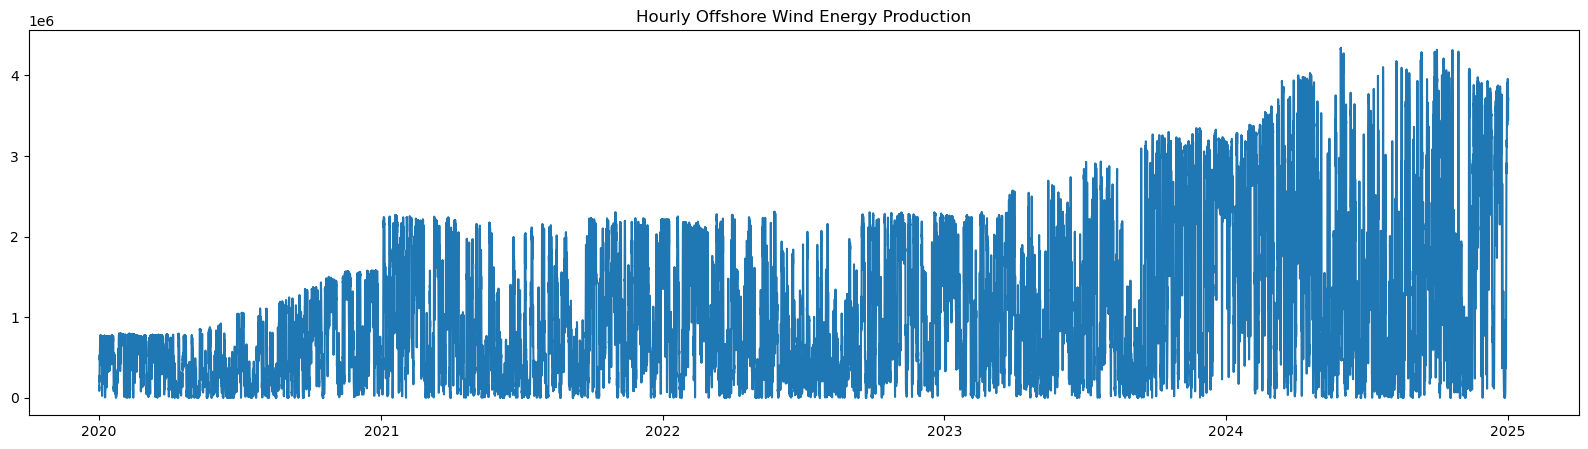

In [254]:
# Build basic time series plot for the 'volume'
plt.figure(figsize=(20, 5))
plt.plot(db_offshore.index, db_offshore['volume'])
plt.title('Hourly Offshore Wind Energy Production')
plt.show()

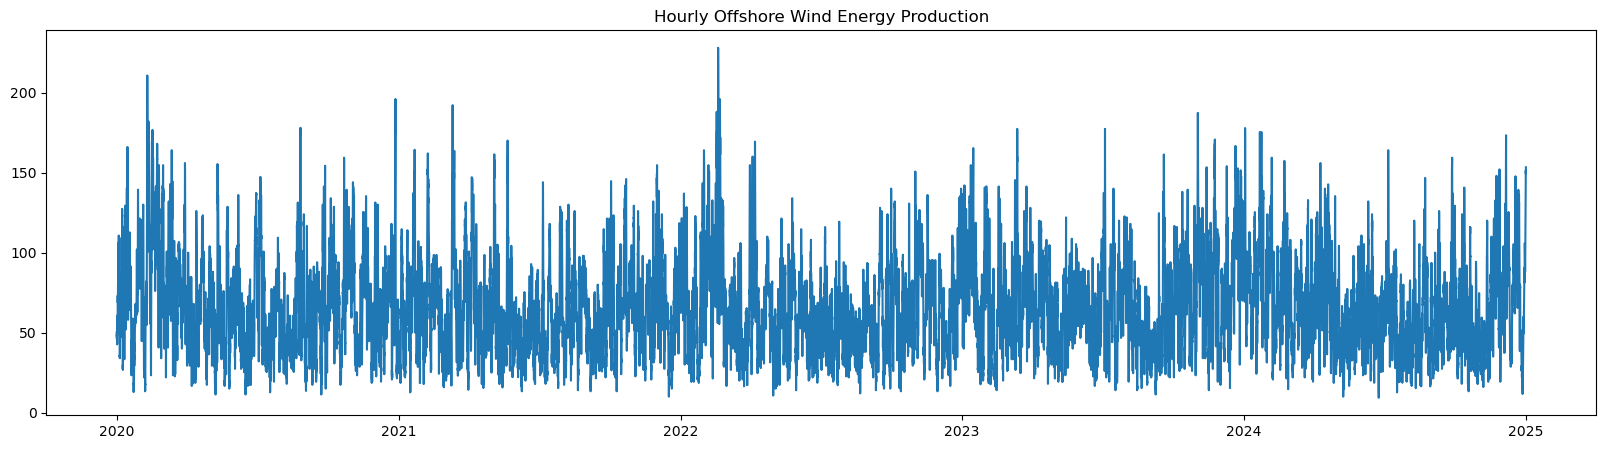

In [255]:
plt.figure(figsize=(20, 5))
plt.plot(db_offshore.index, db_offshore['wind_speed_avg_10'])
plt.title('Hourly Offshore Wind Energy Production')
plt.show()

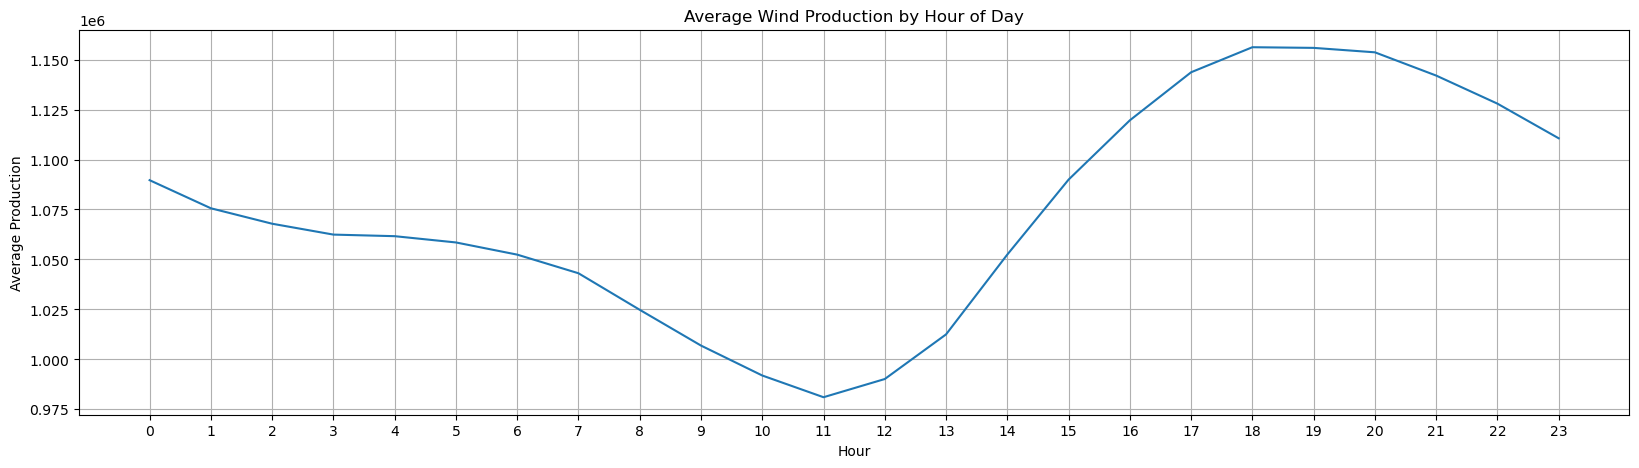

In [256]:
# Check daily patterns (average production by hour of day)
hourly_avg = db_offshore.groupby(db_offshore.index.hour)['volume'].mean()
plt.figure(figsize=(20, 5))
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title('Average Wind Production by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Production')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

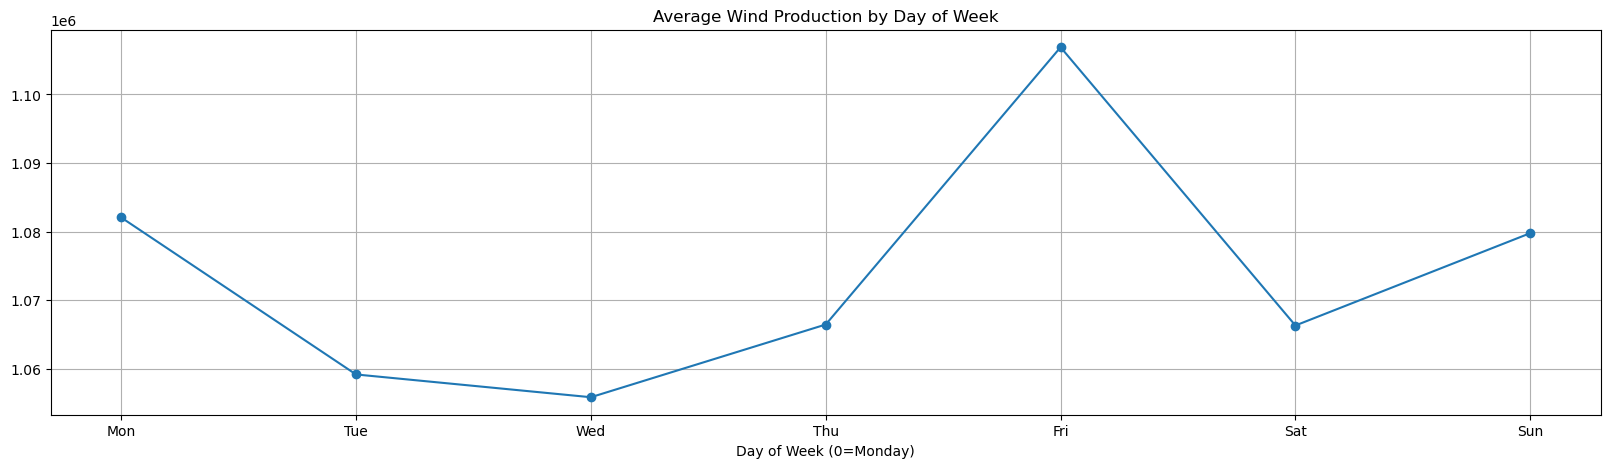

In [257]:
# Check weekly patterns (average by day of week)
daily_avg = db_offshore.groupby(db_offshore.index.dayofweek)['volume'].mean()
plt.figure(figsize=(20, 5))
plt.plot(daily_avg.index, daily_avg.values, marker='o')
plt.title('Average Wind Production by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True)
plt.show()

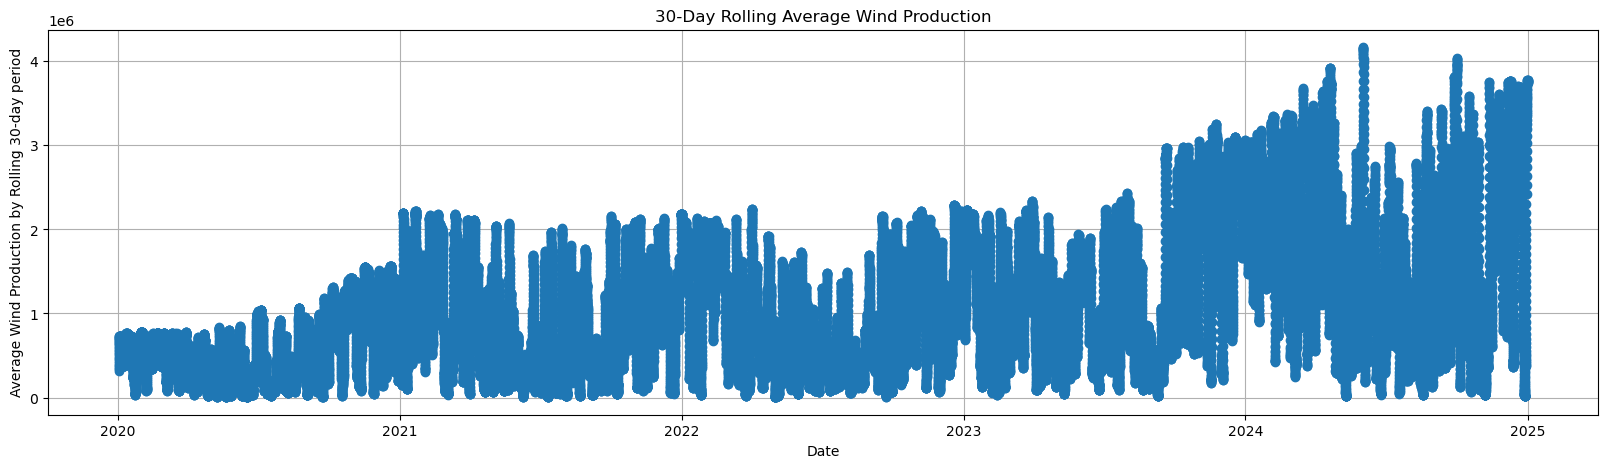

In [258]:
# Check 30-day (rolling) seasonality
rolling_avg = db_offshore['volume'].rolling(window=30).mean()
plt.figure(figsize=(20, 5))
plt.plot(rolling_avg.index, rolling_avg.values, marker='o')
plt.title('30-Day Rolling Average Wind Production')
plt.xlabel('Date')
plt.ylabel('Average Wind Production by Rolling 30-day period')
plt.grid(True)
plt.show()

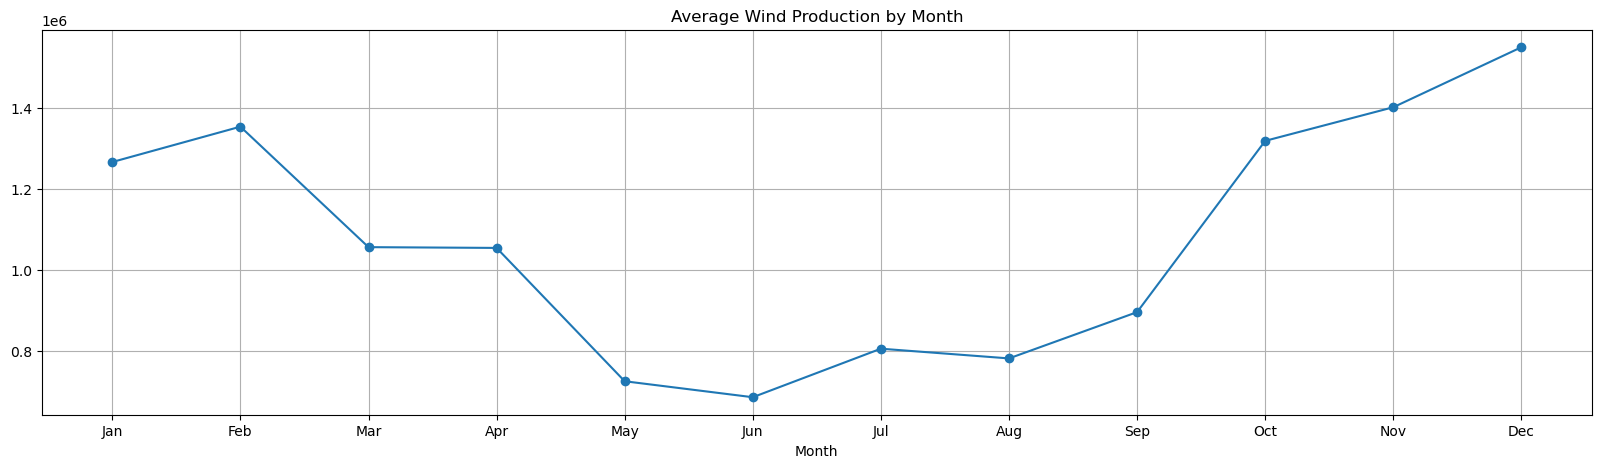

In [259]:
# Check monthly patterns
monthly_avg = db_offshore.groupby(db_offshore.index.month)['volume'].mean()
plt.figure(figsize=(20, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.title('Average Wind Production by Month')
plt.xlabel('Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

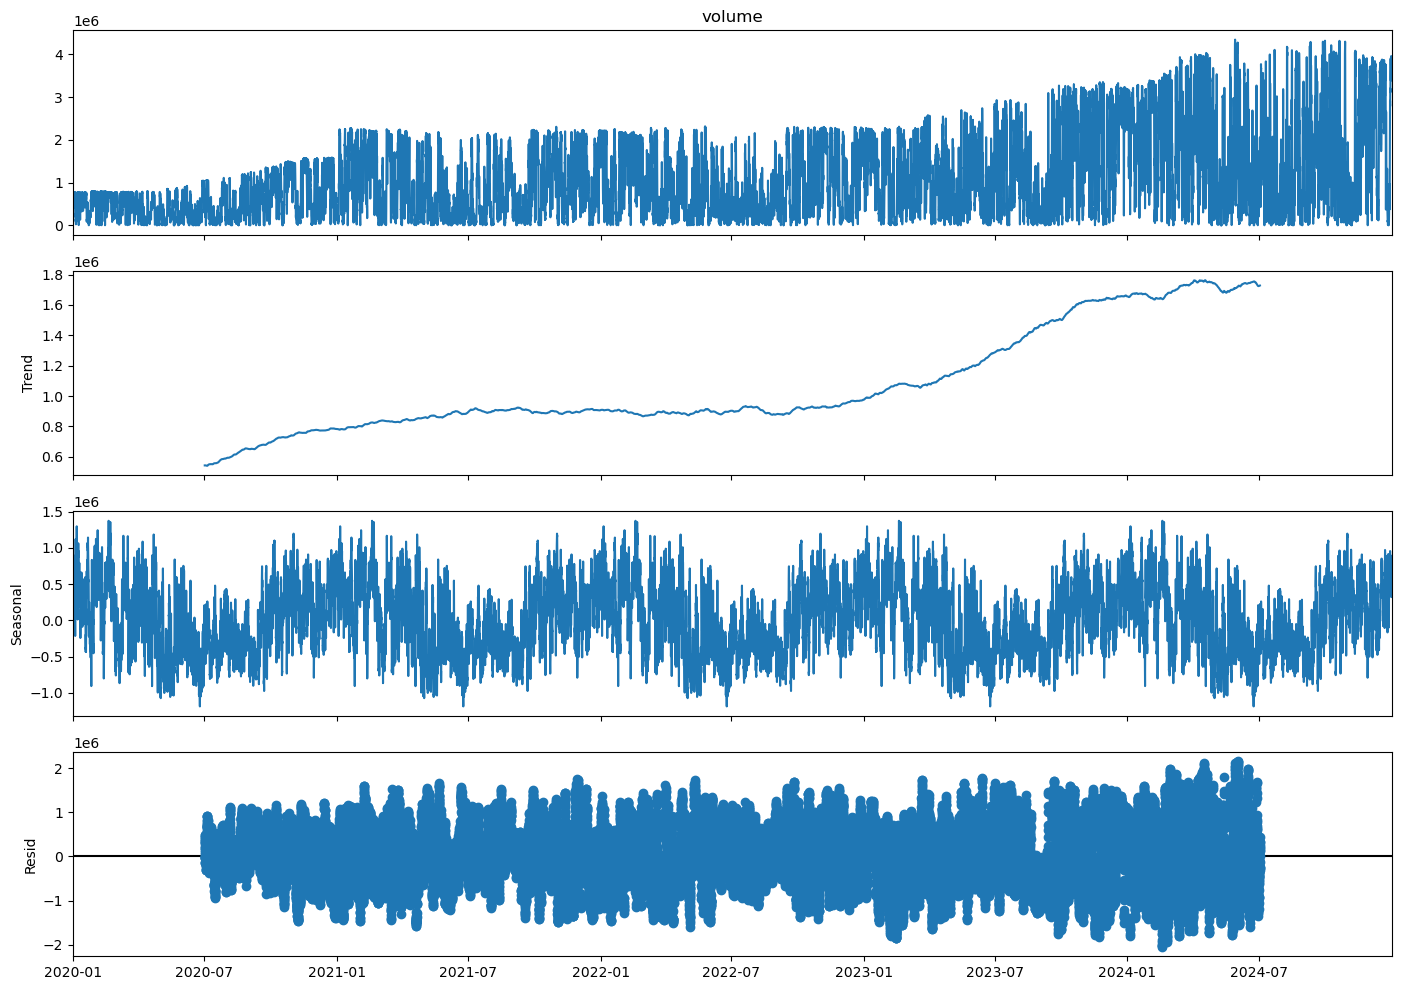

In [260]:
# Analyse annual seasonality with seasonal decomposition graphs
decomposition = seasonal_decompose(db_offshore['volume'], 
                                 model='additive', 
                                 period=8760)  # Annual seasonality
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

**Findings**:

1. Increasing trend

2. Annual seasonality confirmed and consistent across years

3. Residuals show an increasing variance over time (potential heteroscedasticity) 

**Suggestions for the SARIMAX model**:
- Base ARIMA component: Use (2,1,0) or (3,1,0) based on the clear trend shown here
- Seasonal component: Since annual seasonality is dominant, consider:
(a) Using dummy variables for months as exogenous variables
(b) Setting a more manageable seasonal period (s=24 for daily) while accounting for the annual pattern through exogenous variables
- Trend confirms the need for differencing (d=1) in your ARIMA component.

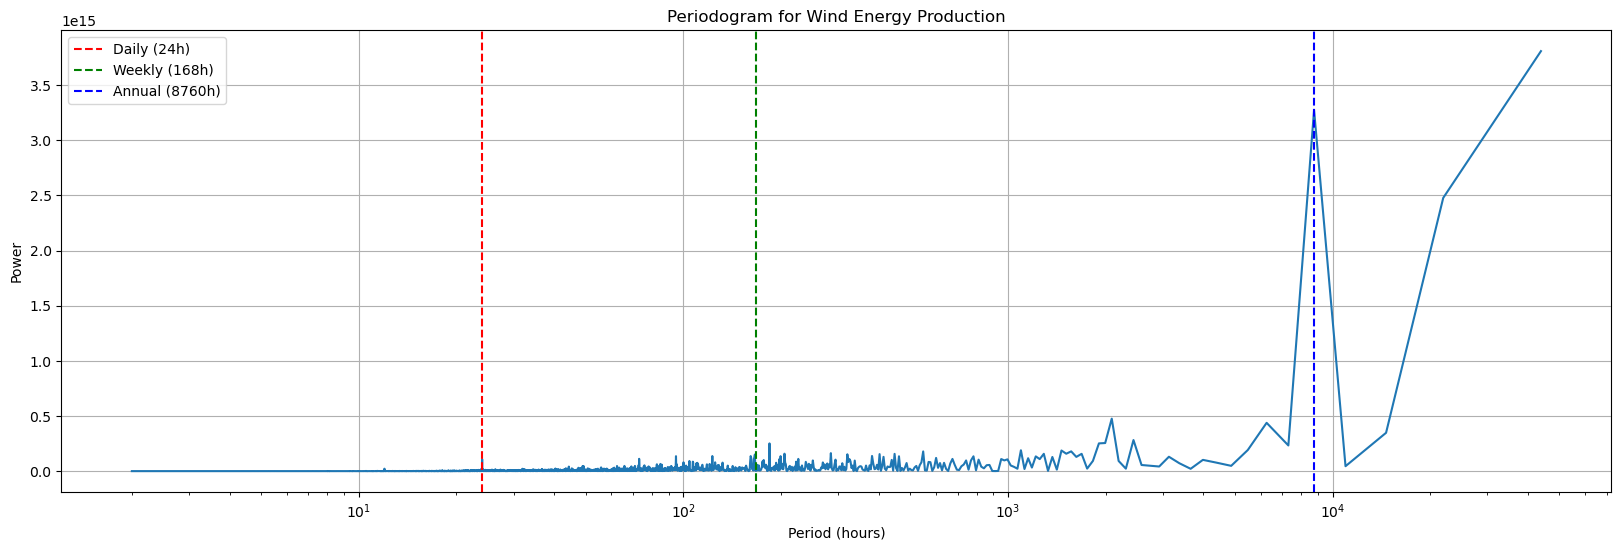

In [261]:
# Compute periodogram
f, Pxx = signal.periodogram(db_offshore['volume'].values, 
                           fs=1)  # 1 sample per hour

# Convert to periods in hours
periods = 1/f[1:]  # Skip the first element (DC component)
power = Pxx[1:]

plt.figure(figsize=(20, 6))
plt.plot(periods, power)
plt.title('Periodogram for Wind Energy Production')
plt.xlabel('Period (hours)')
plt.ylabel('Power')
plt.xscale('log')
plt.axvline(x=24, color='r', linestyle='--', label='Daily (24h)')
plt.axvline(x=168, color='g', linestyle='--', label='Weekly (168h)')
plt.axvline(x=8760, color='b', linestyle='--', label='Annual (8760h)')
plt.grid(True)
plt.legend()
plt.show()

**Findings:**

1. Annual seasonality dominates: the peak aligns almost perfectly with the annual cycle (8760h)
2. Daily and Weekly cycles are weak
3. The rising pattern at the far right indicates a long-term trend

**Suggestions for the SARIMAX model**:

- Seasonal component (s) should account for annual seasonality (s=8760), but this is computationally challenging for SARIMAX models.
- Alternatives:
- (a) Use s=24 or s=168 with an additional exogenous variable for month/season of year
- (b) Split the data by season and build separate models
- (c) Consider alternative models better suited for multiple seasonality:
- (c1) Prophet (can handle daily, weekly, annual seasonality simultaneously)
- (c2) TBATS (designed for complex seasonal patterns)
- (c3) Neural network models

For SARIMAX:
- ARIMA component: (2-3,1,0)
- Seasonal component: (1,1,0,24) as a computationally feasible option
- Add month-of-year dummy variables as exogenous regressors to capture the annual pattern.

#### 4. Further preprocessing before SARIMAX model: dealing with time-based features

In [262]:
# Load libraries
from sklearn.preprocessing import OneHotEncoder

In [263]:
# Extract time-based features
db_offshore['year'] = db_offshore.index.year
db_offshore['month'] = db_offshore.index.month
db_offshore['hour'] = db_offshore.index.hour
db_offshore['day_of_week'] = db_offshore.index.dayofweek

In [264]:
# Use one-hot encoding to create dummy variables for time-based features
db_offshore['month'] = db_offshore['month'].astype(str)  
month_encoder = OneHotEncoder(drop='first', sparse_output=False)

db_offshore['year'] = db_offshore['year'].astype(str) 
year_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [265]:
# Fit and transform month
month_dummies = month_encoder.fit_transform(db_offshore[['month']])
month_dummy_cols = month_encoder.get_feature_names_out(['month'])
month_dummy_df = pd.DataFrame(month_dummies, columns=month_dummy_cols, index=db_offshore.index)

In [266]:
# Fit and transform year
year_dummies = year_encoder.fit_transform(db_offshore[['year']])
year_dummy_cols = year_encoder.get_feature_names_out(['year'])
year_dummy_df = pd.DataFrame(year_dummies, columns=year_dummy_cols, index=db_offshore.index)

#### 5. Further preprocessing before SARIMAX model: splitting intro train and test

In [267]:
# Combine preprocessed features with existing database
preprocessed_db = pd.concat([db_offshore['date'], db_offshore['volume'], db_offshore['wind_speed_h_avg'], month_dummy_df, year_dummy_df], axis=1)

In [268]:
# Split the set to train and test
train_db = preprocessed_db[
    (preprocessed_db['date'] >= '2022-01-01') & 
    (preprocessed_db['date'] < '2024-01-01')
    ]
test_db = preprocessed_db[
    (preprocessed_db['date'] >= '2024-01-01') &
    (preprocessed_db['date'] < '2024-03-01')
    ]

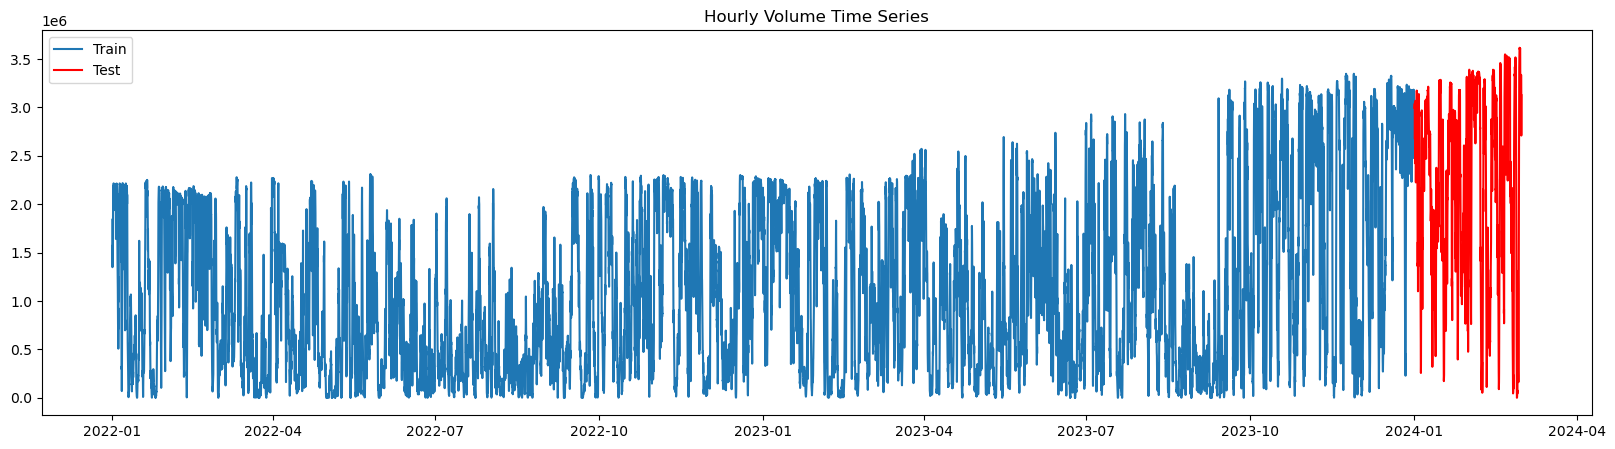

In [269]:
# Plot the target variable
plt.figure(figsize=(20,5))
plt.plot(train_db['volume'], label="Train")
plt.plot(test_db['volume'], label="Test", color='red')
plt.legend()
plt.title("Hourly Volume Time Series")
plt.show()

In [270]:
train_db = train_db.drop(columns=['date'])
test_db = test_db.drop(columns=['date'])

#### 6. Try SARIMAX model

In [271]:
# Load libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX

In [272]:
#exog_vars = train_db.columns.drop('volume')

In [273]:
# Standartise exogenous variables
#scaler = StandardScaler()
#train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
#test_exog_scaled = scaler.transform(test_db[exog_vars])

In [274]:
# Fit the model (processing time 7m 16 seconds for 24 (daily) seasonality)
#model = SARIMAX(
        #train_db['volume'], 
        #exog=train_exog_scaled,
        #order=(3,1,0),  # ARIMA components
        #seasonal_order=(1,1,1,24)  # Seasonal components
    #)
#model_fit = model.fit(disp=True)

In [275]:
# Predict 
#predictions = model_fit.predict(start=len(train_db['volume']), end=len(train_db['volume']) + len(test_db['volume']) - 1, exog=test_exog_scaled, dynamic=False)

In [276]:
# Plot predictions
#plt.figure(figsize=(18,5))
#plt.plot(train_db['volume'], label="Train")
#plt.plot(test_db['volume'], label="Actual", color='red')
#plt.plot(predictions, label="Predicted", color='green')
#plt.legend()
#plt.title("SARIMAX Forecast vs Actual Volume")
#plt.show()

In [277]:
# Compute RMSE
#rmse = np.sqrt(mean_squared_error(test_db['volume'], predictions))
#print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

In [278]:
#data_mean = np.mean(test_db['volume'])
#rmse_percentage = (rmse / data_mean) * 100
#print(rmse_percentage)

#### 7. Try Holt-Winters model

In [279]:
# Load libraries
#from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [280]:
#Holt-Winters Additive with Exogenous Variables
#hw_add_model = ExponentialSmoothing(train_db['volume'], 
                                    #trend='add',
                                    #seasonal='add',  # Additive seasonality
                                    #seasonal_periods=168
                                    #).fit()

In [281]:
#hw_add_forecast = hw_add_model.forecast(len(test_db['volume']))

In [282]:
#plt.figure(figsize=(18,5))
#plt.plot(train_db['volume'], label="Train")
#plt.plot(test_db['volume'], label="Actual", color='red')
#plt.plot(hw_add_forecast, label="Predicted", color='green')
#plt.legend()
#plt.title("Holt-Winters Forecast vs Actual Volume")
#plt.show()

In [283]:
# Compute RMSE
#rmse_h_w = np.sqrt(mean_squared_error(test_db['volume'], hw_add_forecast))
#print(f'Root Mean Squared Error (RMSE): {rmse_h_w:.2f}')

In [284]:
#rmse_h_w_percentage = (rmse_h_w / data_mean) * 100
#print(rmse_h_w_percentage)

### Alt take (29.03.2025)

#### 1. Change the train and test sets

In [285]:
# Include all features
prep_db_alt = pd.concat([db_offshore['date'], 
                         db_offshore['volume'], 
                         db_offshore['wind_speed_h_avg'], 
                         db_offshore['air_pressure'], 
                         db_offshore['humidity'], 
                         db_offshore['wind_dir_avg_10'], 
                         month_dummy_df, 
                         year_dummy_df], axis=1)


In [286]:
# Split the new set to train and test
train_db = prep_db_alt[
    (prep_db_alt['date'] >= '2023-12-25') & 
    (prep_db_alt['date'] < '2024-12-23')
    ] # last week of 2023 + all weeks of 2024 except for the last week
test_db = prep_db_alt[
    (prep_db_alt['date'] >= '2024-12-23') &
    (prep_db_alt['date'] <= '2024-12-29')
    ] # last week of 2024

train_db = train_db.drop(columns=['date'])
test_db = test_db.drop(columns=['date'])

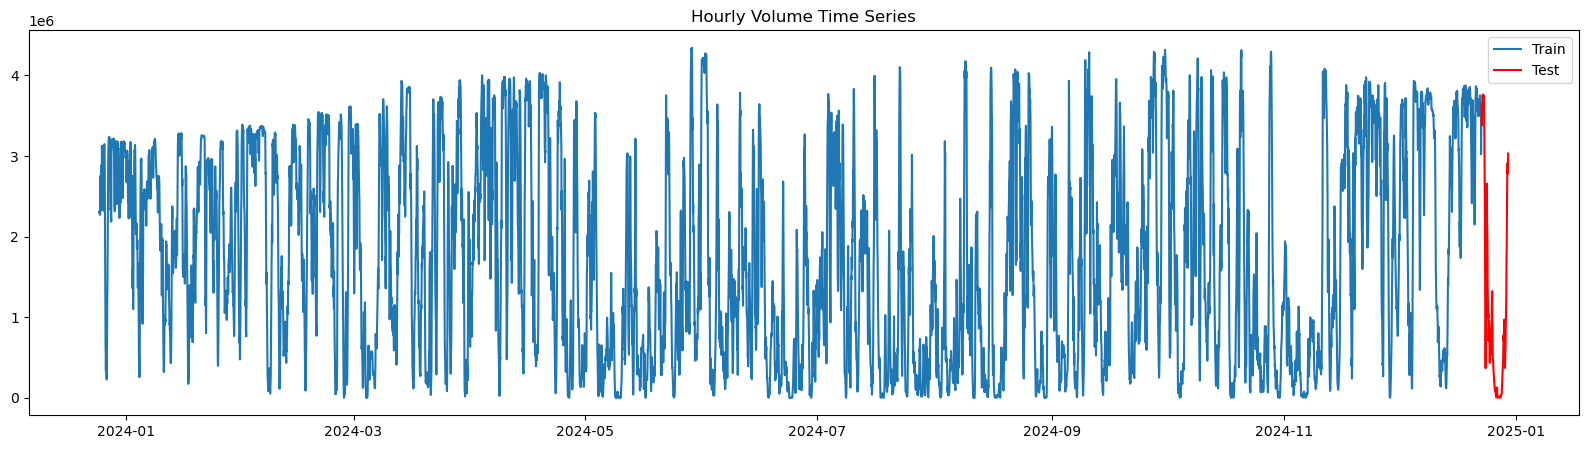

In [287]:
# Plot the target variable for the new train and test split
plt.figure(figsize=(20,5))
plt.plot(train_db['volume'], label="Train")
plt.plot(test_db['volume'], label="Test", color='red')
plt.legend()
plt.title("Hourly Volume Time Series")
plt.show()

#### 2. Run Sarimax will all features

In [288]:
# Run sarimax for the new dataset with all features
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_vars = train_db.columns.drop('volume')

scaler = StandardScaler()
train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
test_exog_scaled = scaler.transform(test_db[exog_vars])

In [289]:
model = SARIMAX(
        train_db['volume'], 
        exog=train_exog_scaled,
        order=(3,1,0),  # ARIMA components
        seasonal_order=(1,1,1,24)  # Seasonal components
    )
model_fit = model.fit(disp=True)

# Seasonality above 24 takes too much time to fit the model (I tried 365 and 8760, but both models took more than 10 minutes. I interrupted the fitting after 15 minutes of work).

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [290]:
# Predict 
predictions = model_fit.predict(start=len(train_db['volume']), end=len(train_db['volume']) + len(test_db['volume']) - 1, exog=test_exog_scaled, dynamic=False)

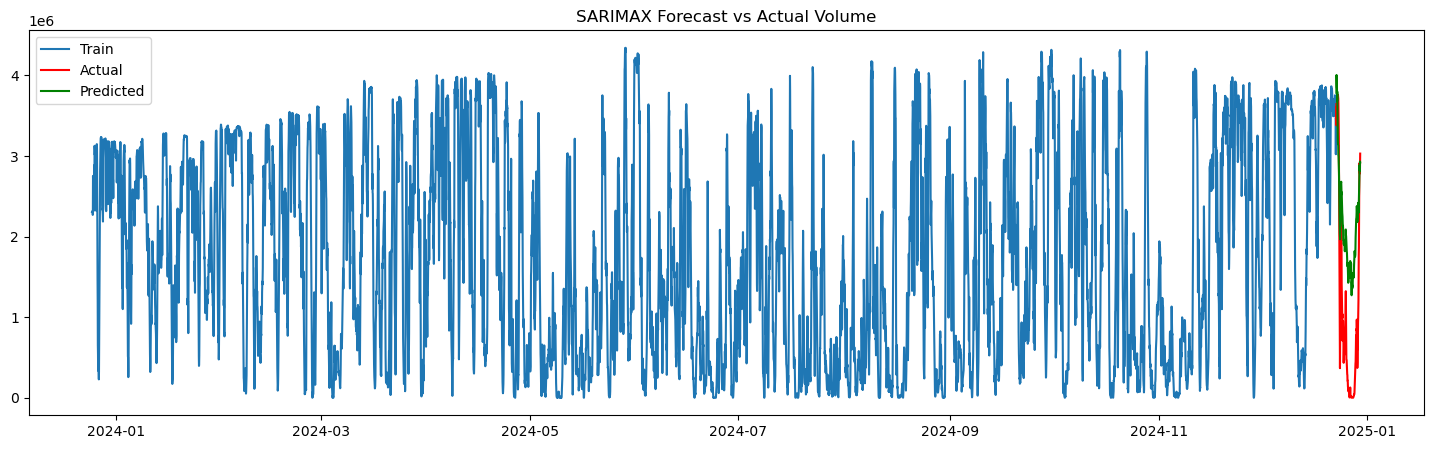

In [291]:
# Plot predictions
plt.figure(figsize=(18,5))
plt.plot(train_db['volume'], label="Train")
plt.plot(test_db['volume'], label="Actual", color='red')
plt.plot(predictions, label="Predicted", color='green')
plt.legend()
plt.title("SARIMAX Forecast vs Actual Volume")
plt.show()

In [292]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(test_db['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Root Mean Squared Error (RMSE): 1240411.03


In [293]:
data_mean = np.mean(test_db['volume'])
rmse_percentage = (rmse / data_mean) * 100
print(rmse_percentage)

116.98393598808899


#### 3. Check the data set for daily data

In [294]:
db_off_new = pd.read_csv('https://raw.githubusercontent.com/benrodion/Watts-next/main/data/final_offshore_data_2017_2025.csv')

In [295]:
db_off_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70151 entries, 0 to 70150
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year_mon_day       70151 non-null  int64  
 1   hour               70151 non-null  int64  
 2   wind_dir_avg_10    70151 non-null  float64
 3   wind_speed_h_avg   70151 non-null  float64
 4   wind_speed_avg_10  70151 non-null  float64
 5   air_pressure       70151 non-null  float64
 6   humidity           70151 non-null  float64
 7   full_datetime      70151 non-null  object 
 8   capacity           70151 non-null  int64  
 9   volume             70151 non-null  int64  
 10  percentage         70151 non-null  float64
 11  emission           70151 non-null  int64  
 12  emissionfactor     70151 non-null  int64  
 13  correct_days       70151 non-null  object 
dtypes: float64(6), int64(6), object(2)
memory usage: 7.5+ MB


In [296]:
db_off_new['date'] = pd.to_datetime(db_off_new['year_mon_day'], format='%Y%m%d')
db_off_new = db_off_new.drop(columns=['hour', 'full_datetime', 'correct_days', 'emissionfactor', 'year_mon_day'])

In [297]:
df_daily_avg = db_off_new.groupby(db_off_new['date'].dt.date).mean()

In [298]:
df_daily_avg.head(3)

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,capacity,volume,percentage,emission,date
date,,,,,,,,,,
2017-01-01,228.565180,80.059524,79.285714,10168.739583,93.851190,695740.000000,695740.000000,0.807778,0.0,2017-01-01
2017-01-02,329.860244,72.142857,72.797619,10228.416667,74.547619,757646.000000,757646.000000,0.879654,0.0,2017-01-02
2017-01-03,273.492887,94.821429,95.744048,10197.416667,84.297619,852552.333333,852552.333333,0.989843,0.0,2017-01-03


In [299]:
df_daily_avg.set_index('date', inplace=True)

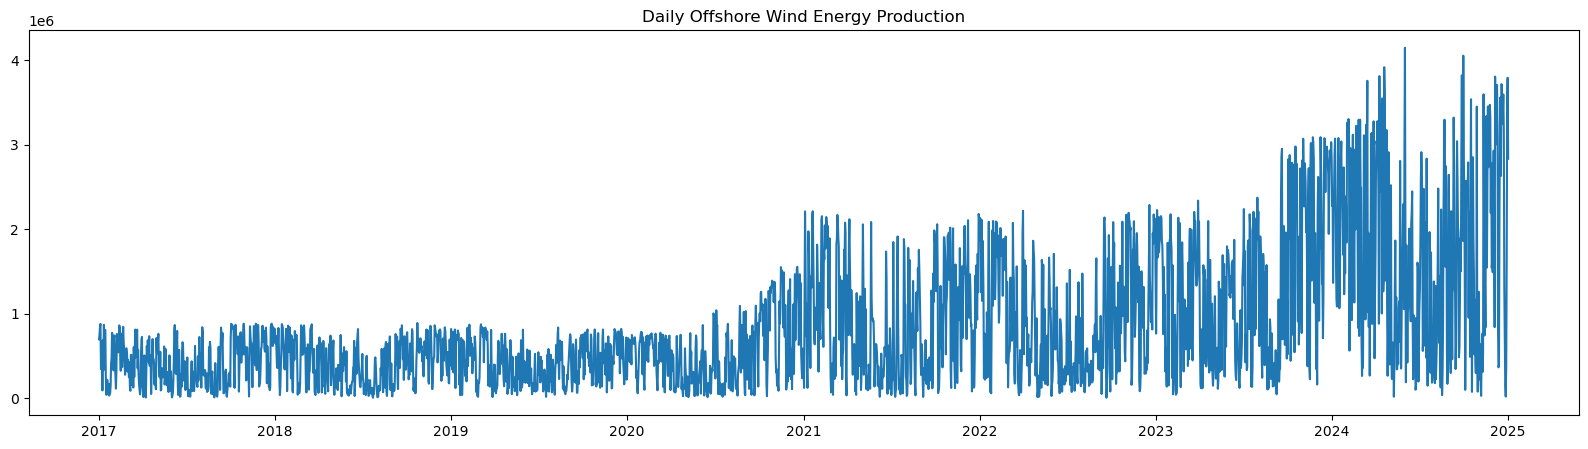

In [300]:
plt.figure(figsize=(20, 5))
plt.plot(df_daily_avg.index, df_daily_avg['volume'])
plt.title('Daily Offshore Wind Energy Production')
plt.show()

In [301]:
# Limit the db to the last 5 years (2020-2024) and removing data for '2025-01-01'
df_daily_avg = df_daily_avg[(df_daily_avg.index >= '2020-01-01') & (df_daily_avg.index < '2025-01-01')]

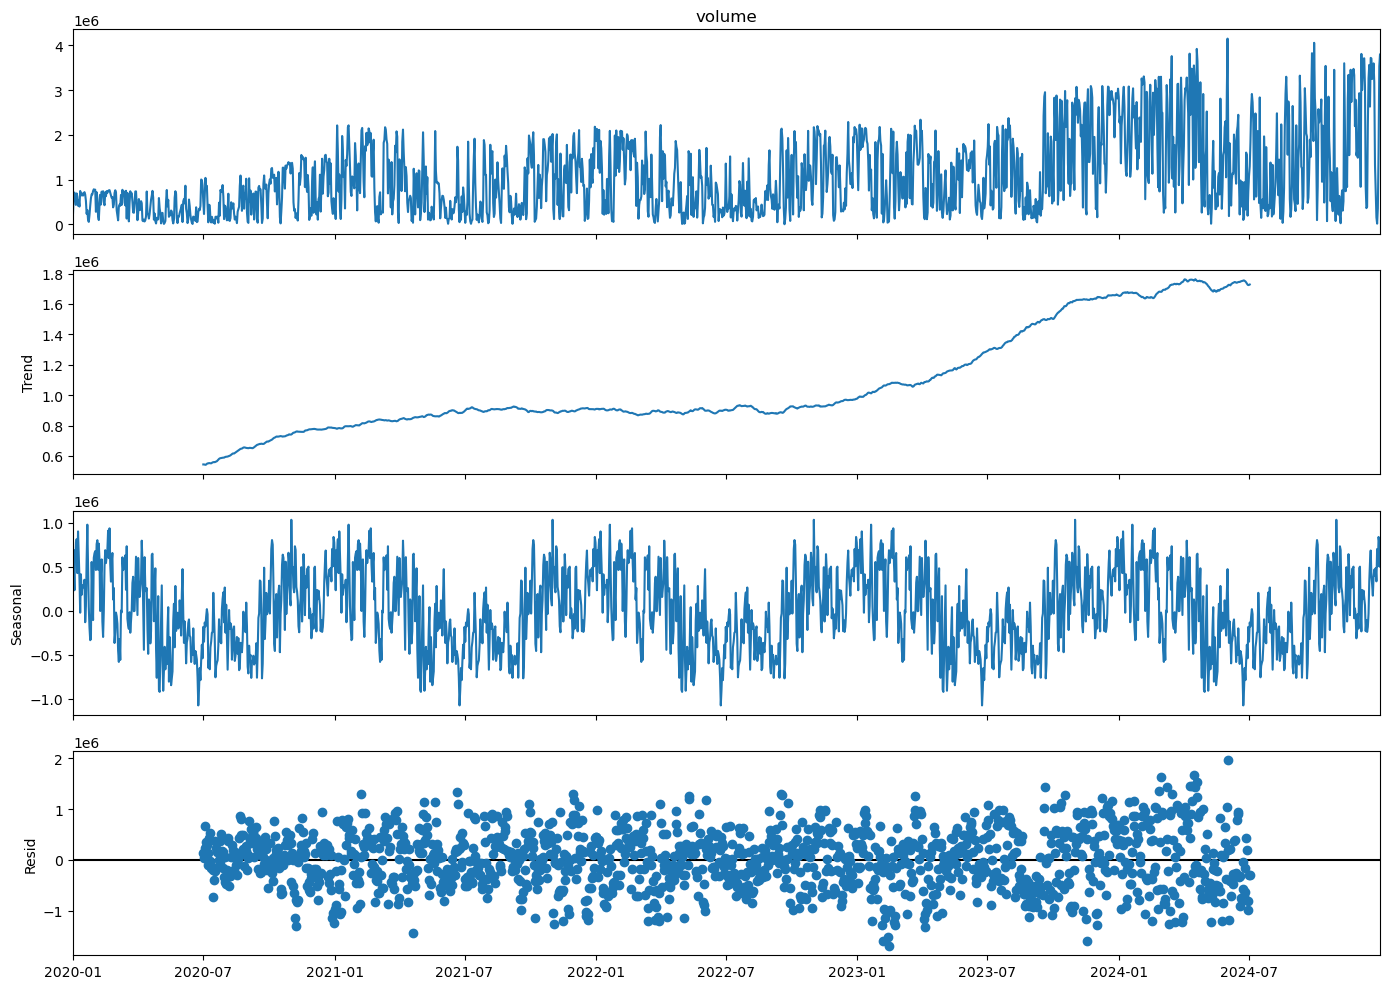

In [302]:
# Analyse annual seasonality with seasonal decomposition graphs
decomposition = seasonal_decompose(df_daily_avg['volume'], 
                                 model='additive', 
                                 period=365)  # Annual seasonality
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

In [303]:
df_daily_avg['year'] = df_daily_avg.index.year
df_daily_avg['month'] = df_daily_avg.index.month

df_daily_avg['month'] = df_daily_avg['month'].astype(str)  
month_encoder = OneHotEncoder(drop='first', sparse_output=False)

df_daily_avg['year'] = df_daily_avg['year'].astype(str) 
year_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [304]:
month_dummies = month_encoder.fit_transform(df_daily_avg[['month']])
month_dummy_cols = month_encoder.get_feature_names_out(['month'])
month_dummy_df = pd.DataFrame(month_dummies, columns=month_dummy_cols, index=df_daily_avg.index)

In [305]:
year_dummies = year_encoder.fit_transform(df_daily_avg[['year']])
year_dummy_cols = year_encoder.get_feature_names_out(['year'])
year_dummy_df = pd.DataFrame(year_dummies, columns=year_dummy_cols, index=df_daily_avg.index)

In [306]:
df_daily_avg = df_daily_avg.reset_index()  # Ensure date is a column before concat

final_daily_db = pd.concat([
    df_daily_avg[['date', 'volume', 'wind_speed_h_avg']],  # Select necessary columns
    month_dummy_df.reset_index(drop=True),  # Reset index to align correctly
    year_dummy_df.reset_index(drop=True)
], axis=1).set_index('date')

In [307]:
final_daily_db.head(3)

,volume,wind_speed_h_avg,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,year_2021,year_2022,year_2023,year_2024
date,,,,,,,,,,,,,,,,,
2020-01-01,256281.291667,51.277778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02,697604.208333,78.277778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-03,710208.333333,89.555556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [308]:
train_db = final_daily_db[
    (final_daily_db.index >= '2023-12-25') & 
    (final_daily_db.index < '2024-12-23')
    ] # last week of 2023 + all weeks of 2024 except for the last week
test_db = final_daily_db[
    (final_daily_db.index >= '2024-12-23') &
    (final_daily_db.index <= '2024-12-29')
    ] # last week of 2024

In [309]:
#train_db = train_db.reset_index().drop(['date'], axis=1)
#train_db.head(3)

In [310]:
#test_db = test_db.reset_index().drop(['date'], axis=1)
#test_db.head(3)

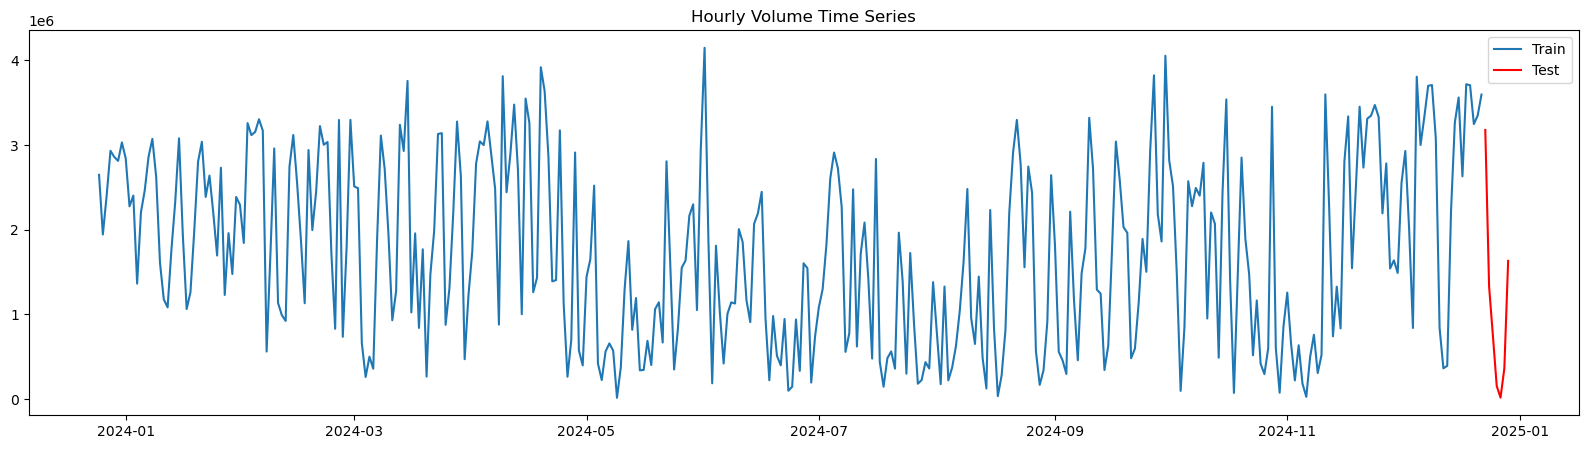

In [311]:
plt.figure(figsize=(20,5))
plt.plot(train_db['volume'], label="Train")
plt.plot(test_db['volume'], label="Test", color='red')
plt.legend()
plt.title("Hourly Volume Time Series")
plt.show()

In [312]:
exog_vars = train_db.columns.drop('volume')

scaler = StandardScaler()
train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
test_exog_scaled = scaler.transform(test_db[exog_vars])

In [313]:
model = SARIMAX(
        train_db['volume'], 
        exog=train_exog_scaled,
        order=(3,1,0),  # ARIMA components
        seasonal_order=(1,1,1,12)  # Seasonal components
    )
model_fit = model.fit(disp=True)

/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kirillkharlashkin/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [314]:
predictions = model_fit.predict(start=len(train_db['volume']), end=len(train_db['volume']) + len(test_db['volume']) - 1, exog=test_exog_scaled, dynamic=False)

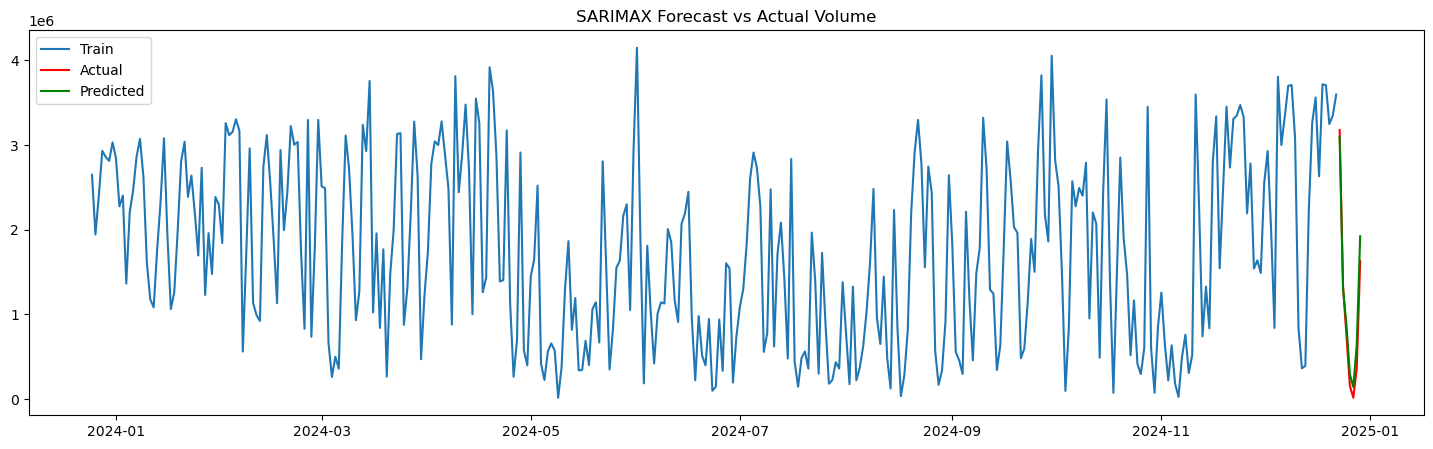

In [315]:
plt.figure(figsize=(18,5))
plt.plot(train_db['volume'], label="Train")
plt.plot(test_db['volume'], label="Actual", color='red')
plt.plot(predictions, label="Predicted", color='green')
plt.legend()
plt.title("SARIMAX Forecast vs Actual Volume")
plt.show()

In [316]:
rmse = np.sqrt(mean_squared_error(test_db['volume'], predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Root Mean Squared Error (RMSE): 178176.27


In [317]:
data_mean = np.mean(test_db['volume'])
rmse_percentage = (rmse / data_mean) * 100
print(rmse_percentage)

16.80391467722936


In [318]:
# Optimal model

#model = SARIMAX(
        #train_db['volume'], 
        #exog=train_exog_scaled,
        #order=(3,1,0),  # ARIMA components
        #seasonal_order=(1,1,1,365)  # Seasonal components (365 days in a year)

In [319]:
# If does not work, use this hint

#from statsmodels.tsa.seasonal import STL
#stl = STL(train_db['volume'], period=365)
#result = stl.fit()
#train_db['deseasonalized'] = train_db['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
#model = SARIMAX(
        #train_db['deseasonalized'], 
        #exog=train_exog_scaled,
        #order=(3,1,0),
        #seasonal_order=(1,1,1,30)  # Use a smaller seasonal period like 30 (monthly) if needed